In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

In [13]:
#전체 구조 요약
df = pd.read_csv("https://raw.githubusercontent.com/parkseolin/bike-sharing-project/main/SeoulBikeData.csv", encoding="ISO-8859-1")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [14]:
#이름 간단히 정리
df.columns = [
    "Date", "Rented_Bike_Count", "Hour", "Temperature", "Humidity",
    "Wind_speed", "Visibility", "Dew_point_temperature",
    "Solar_Radiation", "Rainfall", "Snowfall",
    "Seasons", "Holiday", "Functioning_Day"
]

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   str    
 1   Rented_Bike_Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind_speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew_point_temperature  8760 non-null   float64
 8   Solar_Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   str    
 12  Holiday                8760 non-null   str    
 13  Functioning_Day        8760 non-null   str    
dtypes: float64(6), int64(4), str(4)
memory usage: 1.2 MB


In [15]:
# Date를 datetime 타입으로 변환 
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   8760 non-null   datetime64[us]
 1   Rented_Bike_Count      8760 non-null   int64         
 2   Hour                   8760 non-null   int64         
 3   Temperature            8760 non-null   float64       
 4   Humidity               8760 non-null   int64         
 5   Wind_speed             8760 non-null   float64       
 6   Visibility             8760 non-null   int64         
 7   Dew_point_temperature  8760 non-null   float64       
 8   Solar_Radiation        8760 non-null   float64       
 9   Rainfall               8760 non-null   float64       
 10  Snowfall               8760 non-null   float64       
 11  Seasons                8760 non-null   str           
 12  Holiday                8760 non-null   str           
 13  Functioning_Da

In [16]:
df.describe(include="all")

,Date,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning_Day
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,2018-06-01 00:00:00,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,NaN,NaN,NaN
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,NaN,NaN,NaN
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,NaN,NaN,NaN
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000,NaN,NaN,NaN


---
# Part 4. 날씨 변수 EDA

기상 변수(Temperature, Humidity, Wind_speed, Visibility, Dew_point_temperature, Solar_Radiation, Rainfall, Snowfall) 8개에 대해 아래 순서로 진행
1. 변수별 분포 확인
2. Rented_Bike_Count와의 상관관계 (Pearson/Spearman)
3. 산점도 (연속형) / 박스플롯 (0이 많은 변수)
4. 이상치 확인 (IQR + 계기 특성 점검)
5. 기상 변수 간 다중공선성 확인 (상관행렬 + VIF)

In [24]:
import matplotlib.font_manager as fm
plt.rcParams['axes.unicode_minus'] = False
plt.rcdefaults()

In [18]:
weather_cols = ["Temperature", "Humidity", "Wind_speed", "Visibility",
                "Dew_point_temperature", "Solar_Radiation", "Rainfall", "Snowfall"]

# Functioning_Day = "No"인 행(대여량 구조적 0)은 날씨-수요 관계 왜곡을 막기 위해 이 파트에서는 제외
df_w = df[df["Functioning_Day"] == "Yes"].copy()
print(df_w.shape)
df_w[weather_cols].describe()

(8465, 14)


,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall
count,8465.000000,8465.000000,8465.000000,8465.000000,8465.000000,8465.000000,8465.00000,8465.000000
mean,12.771057,58.147194,1.725883,1433.873479,3.944997,0.567868,0.14912,0.077685
std,12.104375,20.484839,1.034281,609.051229,13.242399,0.868245,1.12554,0.444063
min,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.00000,0.000000
25%,3.000000,42.000000,0.900000,935.000000,-5.100000,0.000000,0.00000,0.000000
50%,13.500000,57.000000,1.500000,1690.000000,4.700000,0.010000,0.00000,0.000000
75%,22.700000,74.000000,2.300000,2000.000000,15.200000,0.930000,0.00000,0.000000
max,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.00000,8.800000


## 2-1. 기상 변수별 분포 확인

8개 변수를 두 그룹으로 나눔
- **연속형(정규분포에 가까울 수 있는 변수)**: Temperature, Humidity, Wind_speed, Visibility, Dew_point_temperature
- **0이 대부분인 변수(zero-inflated)**: Solar_Radiation, Rainfall, Snowfall → 분포 모양보다 '0의 비율'과 '0이 아닐 때의 분포'를 따로 봐야 함. 즉 적설량과 강수량의 크기에 따른 강도 효과보다는, 눈/비가 오냐 안오냐의 여부에 따른 분석을 하는게 좋음 (더미변수로 변환 고려)

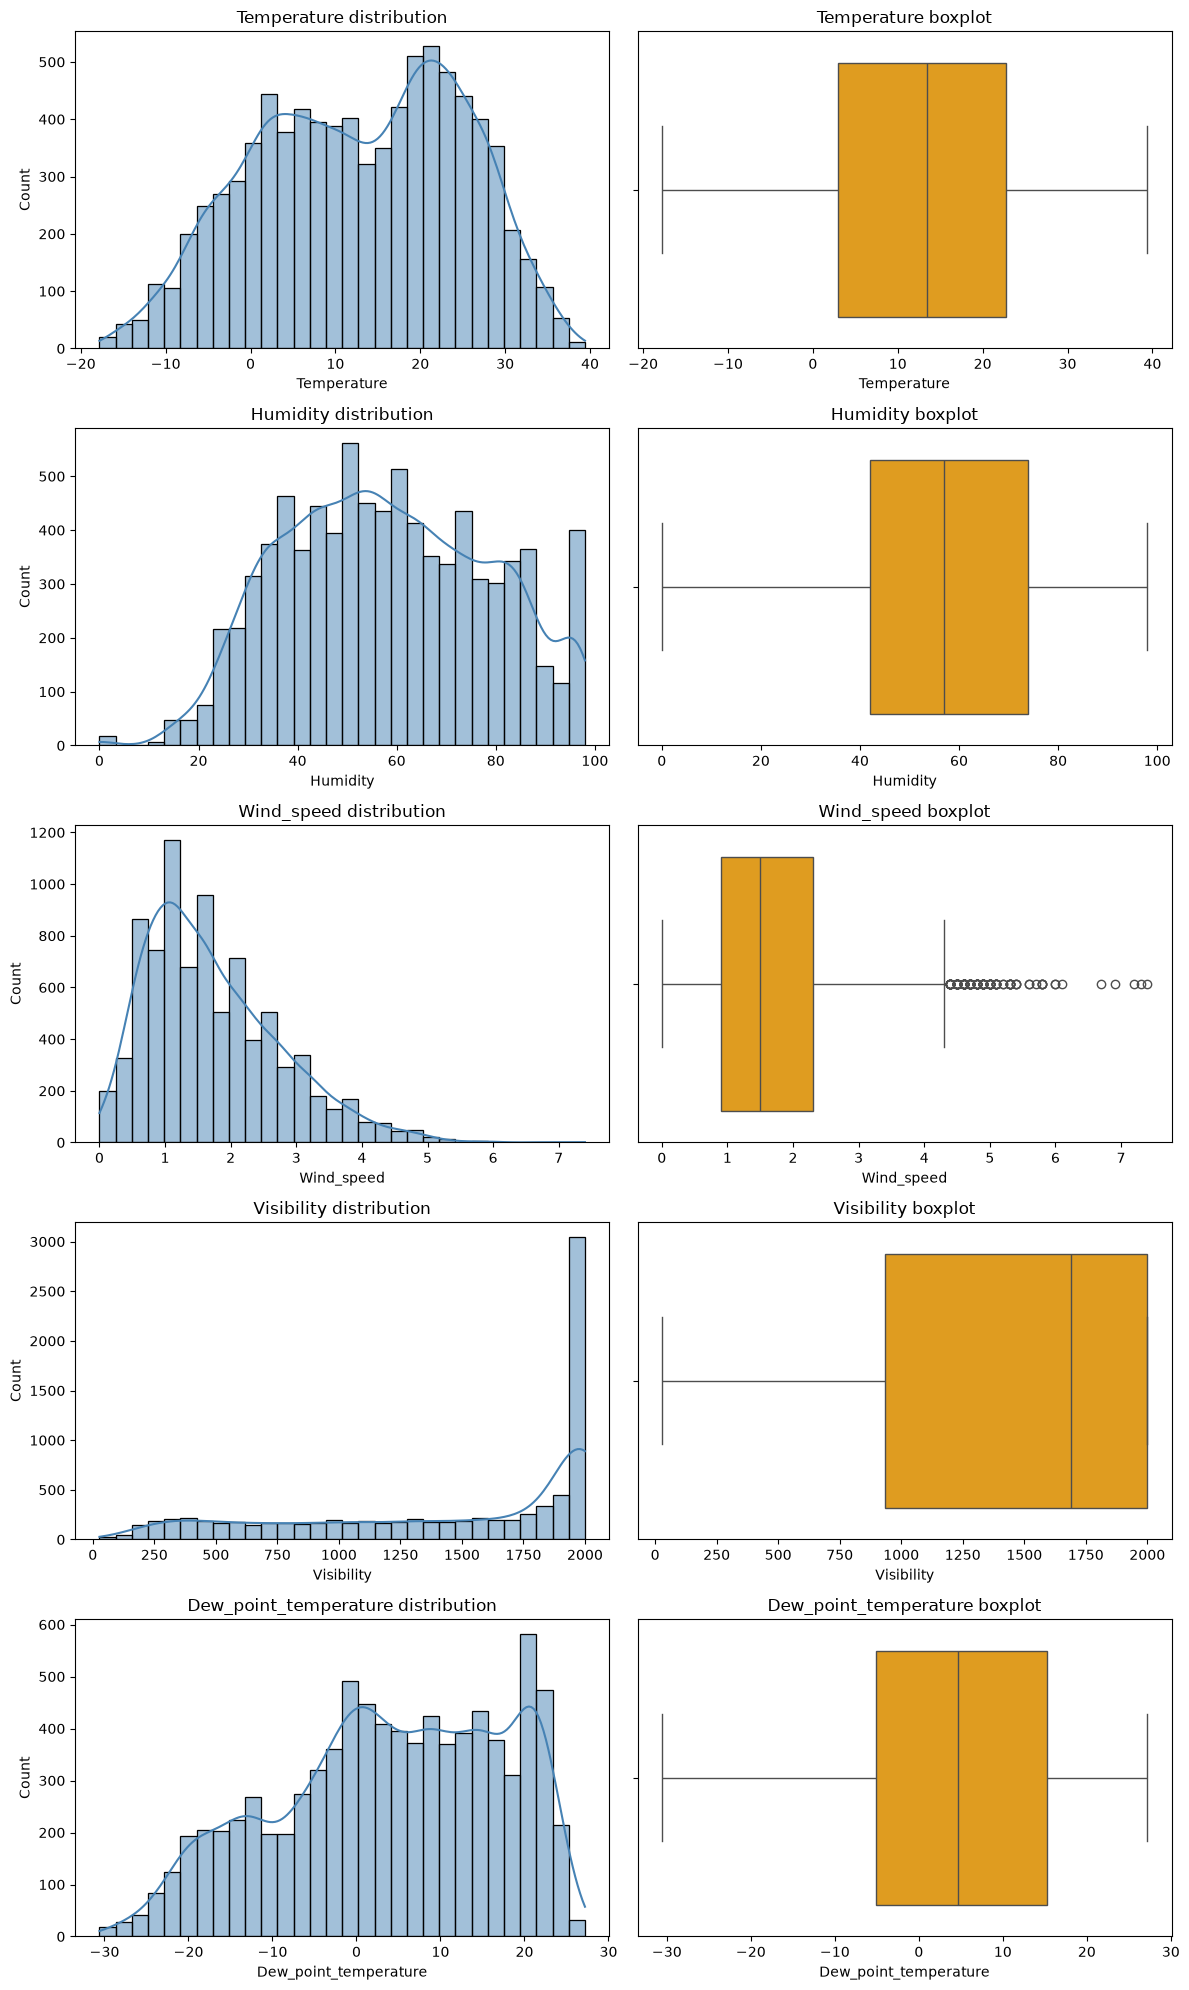

,skewness,mean,std,min,max
Temperature,-0.174519,12.771057,12.104375,-17.8,39.4
Humidity,0.068637,58.147194,20.484839,0.0,98.0
Wind_speed,0.894063,1.725883,1.034281,0.0,7.4
Visibility,-0.695183,1433.873479,609.051229,27.0,2000.0
Dew_point_temperature,-0.338715,3.944997,13.242399,-30.6,27.2


In [25]:
continuous_cols = ["Temperature", "Humidity", "Wind_speed", "Visibility", "Dew_point_temperature"]

fig, axes = plt.subplots(len(continuous_cols), 2, figsize=(12, 4*len(continuous_cols)))
for i, col in enumerate(continuous_cols):
    sns.histplot(df_w[col], bins=30, kde=True, color="steelblue", ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} distribution")
    sns.boxplot(x=df_w[col], color="orange", ax=axes[i, 1])
    axes[i, 1].set_title(f"{col} boxplot")
plt.tight_layout()
plt.show()

skew_table = pd.DataFrame({
    "skewness": [skew(df_w[c]) for c in continuous_cols],
    "mean": [df_w[c].mean() for c in continuous_cols],
    "std": [df_w[c].std() for c in continuous_cols],
    "min": [df_w[c].min() for c in continuous_cols],
    "max": [df_w[c].max() for c in continuous_cols],
}, index=continuous_cols)
skew_table

                 zero_count  zero_ratio(%)  nonzero_mean  nonzero_max
Solar_Radiation        4151           49.0      1.114279         3.52
Rainfall               7949           93.9      2.446318        35.00
Snowfall               8022           94.8      1.484424         8.80


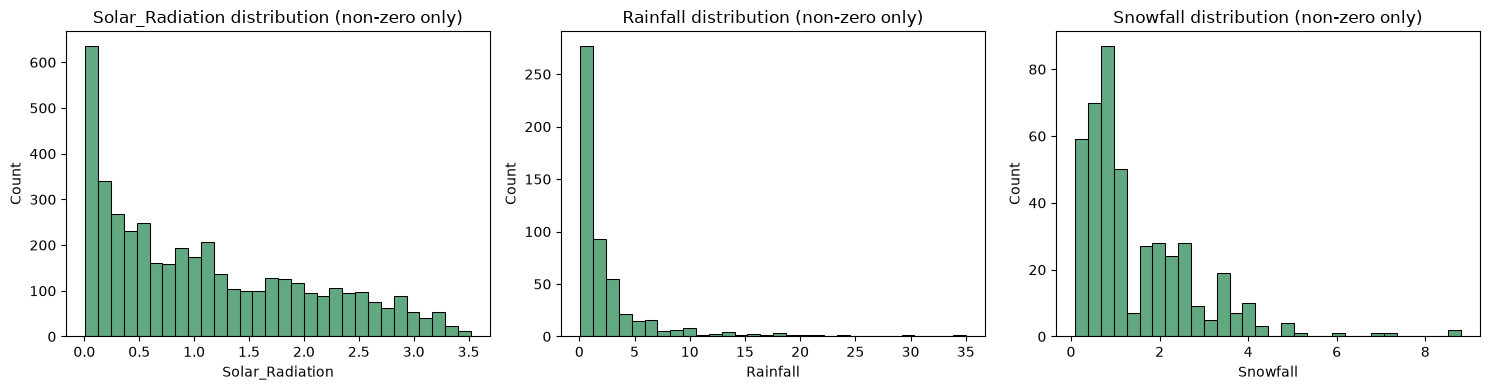

In [27]:
zero_cols = ["Solar_Radiation", "Rainfall", "Snowfall"]

zero_ratio = pd.DataFrame({
    "zero_count": [(df_w[c] == 0).sum() for c in zero_cols],
    "zero_ratio(%)": [round((df_w[c] == 0).mean()*100, 1) for c in zero_cols],
    "nonzero_mean": [df_w.loc[df_w[c] > 0, c].mean() for c in zero_cols],
    "nonzero_max": [df_w.loc[df_w[c] > 0, c].max() for c in zero_cols],
}, index=zero_cols)
print(zero_ratio)

fig, axes = plt.subplots(1, len(zero_cols), figsize=(15, 4))
for i, col in enumerate(zero_cols):
    sns.histplot(df_w.loc[df_w[col] > 0, col], bins=30, color="seagreen", ax=axes[i])
    axes[i].set_title(f"{col} distribution (non-zero only)")
plt.tight_layout()
plt.show()

**분포 확인 결과 :**
- wind_speed와 visibilty의 skewness가 큼. 특히 visibilty는 2000 부근에 관측값이 집중되어 있으며, 상한값에 데이터가 많이 몰려 있는 분포임. temperature,humidity, dew_point_temperature은 비교적 대칭에 가까운 분포
- Solar_Radiation/Rainfall/Snowfall은 0 비율이 매우 높음(특히 Rainfall·Snowfall은 대부분 0) → 이후 상관계수·산점도 해석 시 이 zero-inflation을 반드시 감안

## 2-2. 기상 변수와 Rented_Bike_Count의 상관관계

In [29]:
pearson_corr = df_w[weather_cols].corrwith(df_w["Rented_Bike_Count"], method="pearson")
spearman_corr = df_w[weather_cols].corrwith(df_w["Rented_Bike_Count"], method="spearman")

corr_compare = pd.DataFrame({"Pearson": pearson_corr, "Spearman": spearman_corr})
corr_compare["abs_diff"] = (corr_compare["Pearson"] - corr_compare["Spearman"]).abs()
corr_compare = corr_compare.sort_values("Pearson", key=abs, ascending=False)
corr_compare

,Pearson,Spearman,abs_diff
Temperature,0.562740,0.611726,0.048986
Dew_point_temperature,0.400263,0.410788,0.010526
Solar_Radiation,0.273862,0.409508,0.135646
Visibility,0.212323,0.198904,0.013419
Humidity,-0.201973,-0.226477,0.024504
Snowfall,-0.151611,-0.246787,0.095177
Rainfall,-0.128626,-0.305837,0.177210
Wind_speed,0.125022,0.154984,0.029962


<Figure size 800x500 with 0 Axes>

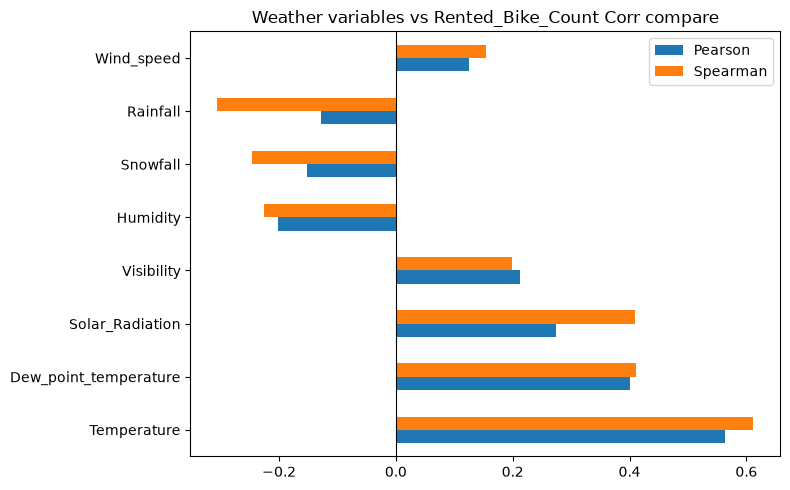

In [31]:
#종속변수와 기상변수의 상관계수 비교 
plt.figure(figsize=(8,5))
corr_compare[["Pearson", "Spearman"]].plot(kind="barh", figsize=(8,5))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Weather variables vs Rented_Bike_Count Corr compare")
plt.tight_layout()
plt.show()

Pearson과 Spearman 값 차이가 큰 변수(abs_diff가 큰 변수)는 두 변수 사이 관계가 '직선형'이 아니라 '비선형'일 가능성을 의미-> 산점도에서 실제 모양을 확인해야함

**결과: Solar_Radiation,Rainfall,Snowfall은 대부분의 값이 0이라는 zero-inflation 구조 때문에 Pearson-Spearman 차이 발생. 즉 비선형관계때문에 차이가 생긴것이 아니라, 0이냐 아니냐라는 이분법적인 구조가 만든 인위적인 차이에 가까움 -> 고려할 필요 X**

**나머지 연속형 변수(Temperature, Humidity, Wind_speed, Visibility, Dew_point_temperature)는 abs_diff가 모두 0.05 이하로 작아 뚜렷한 비선형 패턴 증거 없음**

## 2-3. 산점도 / 박스플롯으로 관계 확인

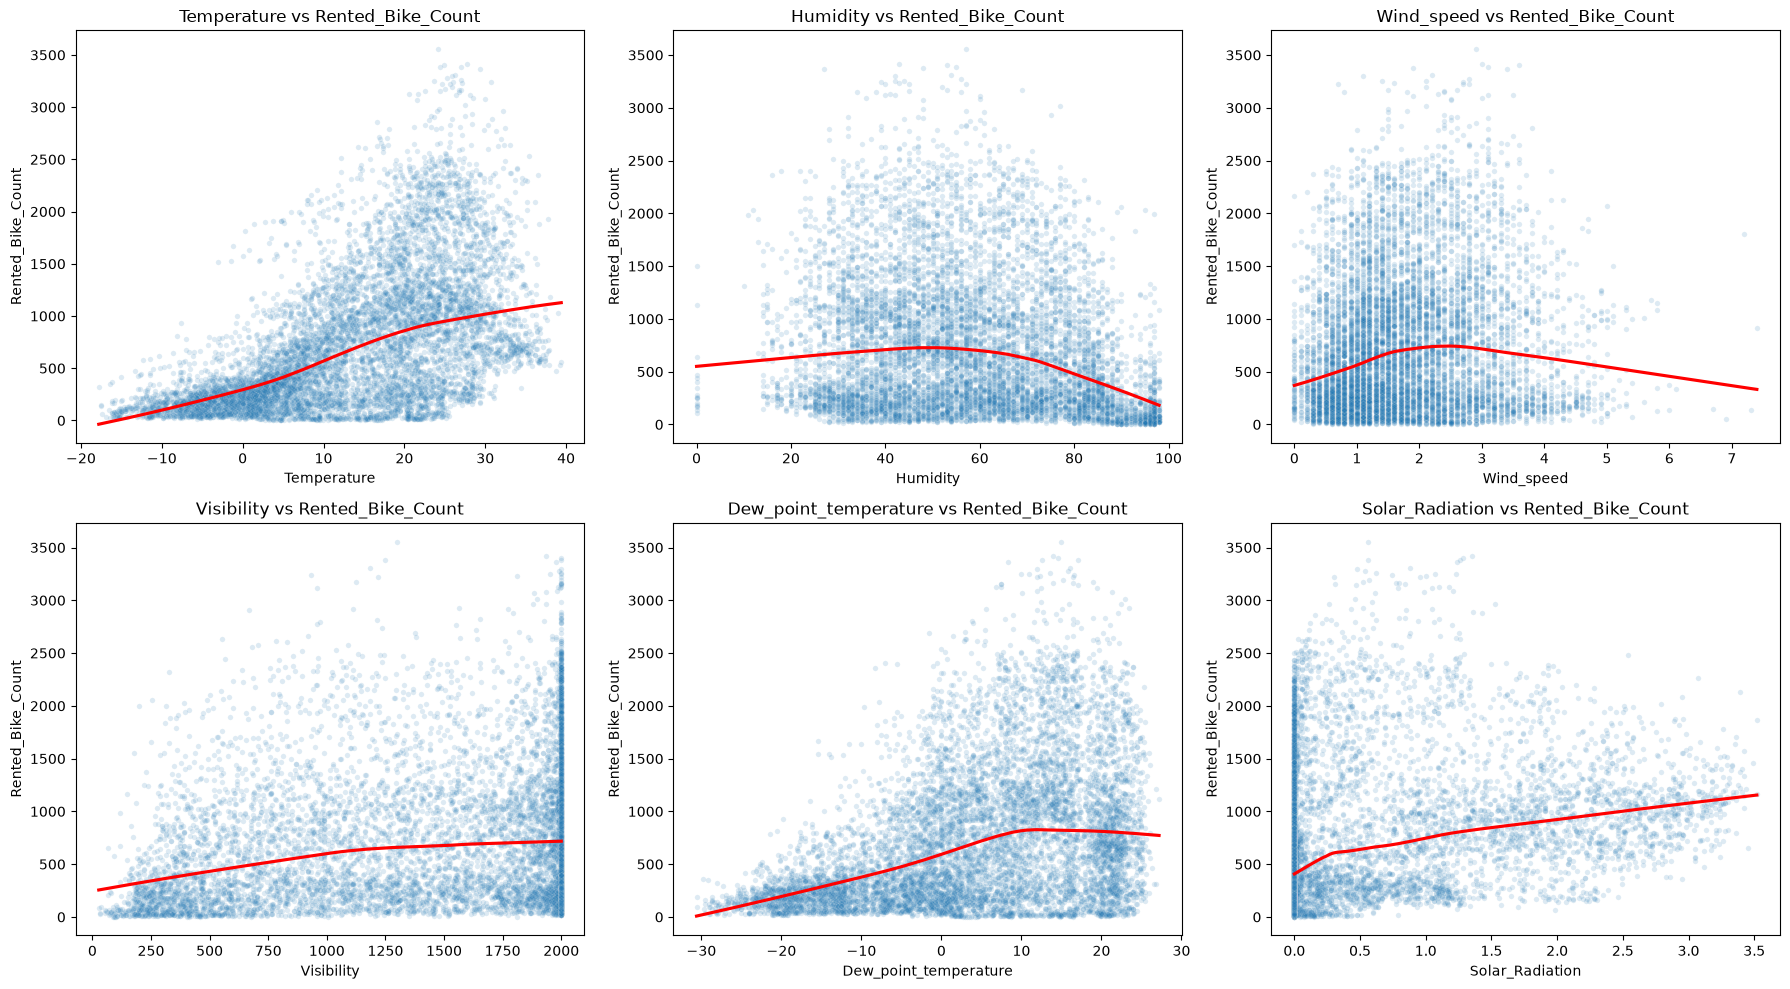

In [32]:
#연속형 변수의 산점도
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(continuous_cols + ["Solar_Radiation"]):
    sns.scatterplot(x=df_w[col], y=df_w["Rented_Bike_Count"], alpha=0.15, s=15, ax=axes[i])
    sns.regplot(x=df_w[col], y=df_w["Rented_Bike_Count"], scatter=False, color="red",
                lowess=True, ax=axes[i])
    axes[i].set_title(f"{col} vs Rented_Bike_Count")
plt.tight_layout()
plt.show()

Temperature:
빨간 선이 완만한 S자 형태를 그리며, 0~25℃ 구간에서는 기온이 오를수록 대여량이 뚜렷하게 증가하다가 25℃ 이상에서는 증가폭이 둔화됨. 일정 구간까지만 선형적으로 증가하고 그 이후 완만해지는 구조로, 상관계수(0.56)가 실제 관계를 어느 정도 잘 반영하고 있는 변수.

Humidity:
추세선이 뚜렷한 역U자 형태. 습도 40~60% 구간에서 대여량이 오히려 가장 높고, 그 이하/이상 구간에서는 낮아짐. 이는 '습도가 높을수록 좋다'는 단순한 선형관계가 아니라 쾌적한 습도 구간이 따로 존재함을 시사하며, Pearson 상관계수(-0.2)만으로는 이 최적구간 패턴이 전혀 드러나지 않음 

Wind_speed:
역시 역U자 형태로, 풍속 2-3 m/s 부근에서 대여량이 가장 높고 그 이상으로 강해지면 감소. 다만 대부분의 관측치가 0-4 m/s에 몰려있어 꼬리 부분(5 m/s 이상)의 추세는 표본이 적어 신뢰도가 낮음.

Visibility:
1000 이하 구간에서는 가시거리가 늘수록 대여량이 뚜렷이 증가하지만, 2000(계기 상한)에 값이 집중돼 있어 이 구간의 추세는 평평하게 수렴. 관계 자체보다는 계기 상한으로 인한 데이터 구조가 추세선 모양에 영향을 준 것으로 해석하는 게 정확함.

Dew_point_temperature:
Temperature와 유사한 완만한 증가 패턴을 보이나, 15~20℃ 부근에서 정점을 찍고 이후 소폭 감소하는 모습. Temperature와 상관계수 0.91로 사실상 같은 정보를 담고 있어 패턴이 거의 겹치는 것이 오히려 다중공선성의 시각적 증거로 볼 수 있음.

Solar_Radiation:
0 부근(야간)에 관측치가 수직으로 몰려 있고 그 위로 넓게 분산된 형태 — 전형적인 zero-inflated 변수의 산점도. 0이 아닌 구간에서는 완만한 우상향 추세를 보이나, "낮이냐 밤이냐"라는 이산적 구분이 추세의 대부분을 설명하며 연속값으로서의 선형 관계는 상대적으로 약함(Pearson 0.27).

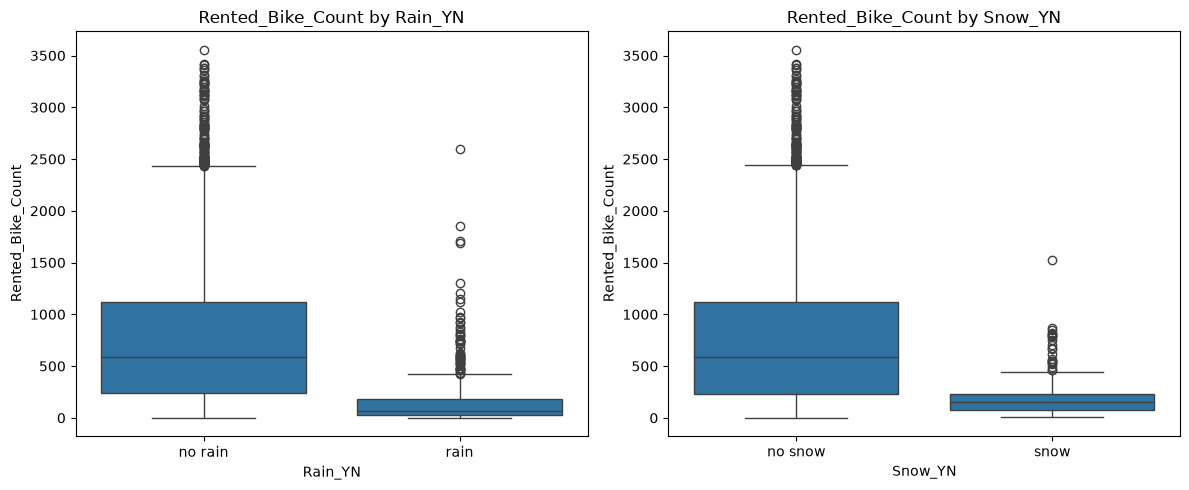

         count        mean  median
Rain_YN                           
no rain   7949  765.632029   591.0
rain       516  167.257752    71.0
         count        mean  median
Snow_YN                           
no snow   8022  759.201446   588.0
snow       443  185.101580   149.0


In [34]:
#zero-inflated 변수의 boxplot
fig, axes = plt.subplots(1, 2, figsize=(12,5))
df_w["Rain_YN"] = np.where(df_w["Rainfall"] > 0, "rain", "no rain")
df_w["Snow_YN"] = np.where(df_w["Snowfall"] > 0, "snow", "no snow")

#강수여부별 수요량
sns.boxplot(x="Rain_YN", y="Rented_Bike_Count", data=df_w, ax=axes[0])
axes[0].set_title("Rented_Bike_Count by Rain_YN")
#적설여부별 수요량
sns.boxplot(x="Snow_YN", y="Rented_Bike_Count", data=df_w, ax=axes[1])
axes[1].set_title("Rented_Bike_Count by Snow_YN")
plt.tight_layout()
plt.show()

print(df_w.groupby("Rain_YN")["Rented_Bike_Count"].agg(["count","mean","median"]))
print(df_w.groupby("Snow_YN")["Rented_Bike_Count"].agg(["count","mean","median"]))

Rainfall,Snowfall은 대부분 0이라 산점도보다 '비/눈이 온 시간 vs 안 온 시간'의 대여량 분포를 박스플롯+평균 비교로 보는 게 더 직관적.
박스플롯 확인 결과 강수/적설 여부(YN)에 따라 대여량 중앙값이 80% 이상 감소하는 뚜렷한 억제 효과를 보임. 
반면 0을 제외한 표본 내 상관계수는 오히려 약해지거나 비슷한 수준(Rainfall -0.147, Snowfall -0.090)으로, **'양'보다 '유무'가 핵심 설명 변수**임을 확인함. 이에 따라 모델링 단계에서는 이진 지표(Rain_YN, Snow_YN)를 원본 값과 함께 사용하는 것을 제안

## 2-4. 기상 변수 이상치 확인 (IQR 기준)

In [35]:
outlier_summary = []
for col in weather_cols:
    Q1, Q3 = df_w[col].quantile(0.25), df_w[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_w[col] < lower) | (df_w[col] > upper)).sum()
    outlier_summary.append([col, round(lower,2), round(upper,2), n_out, round(n_out/len(df_w)*100,2)])

outlier_df = pd.DataFrame(outlier_summary,
                           columns=["variable","lower_bound","upper_bound","outlier_count","outlier_ratio(%)"])
outlier_df

,variable,lower_bound,upper_bound,outlier_count,outlier_ratio(%)
0,Temperature,-26.55,52.25,0,0.00
1,Humidity,-6.00,122.00,0,0.00
2,Wind_speed,-1.20,4.40,154,1.82
3,Visibility,-662.50,3597.50,0,0.00
4,Dew_point_temperature,-35.55,45.65,0,0.00
5,Solar_Radiation,-1.40,2.33,620,7.32
6,Rainfall,0.00,0.00,516,6.10
7,Snowfall,0.00,0.00,443,5.23


In [41]:
# 1번 파트에서 짚었던 계기의 측정 한계와 관련된 특성 두 가지 별도 확인(humidity,visibility)
print("Humidity = 0 인 행 수:", (df_w["Humidity"] == 0).sum())
print(df_w[df_w["Humidity"] == 0][["Date","Hour","Humidity","Temperature","Seasons"]].head())

print("\nVisibility = 2000(상한) 인 행 수:", (df_w["Visibility"] == 2000).sum(),
      f"/ 전체 {len(df_w)} ({round((df_w['Visibility']==2000).mean()*100,1)}%)")

Humidity = 0 인 행 수: 17
           Date  Hour  Humidity  Temperature Seasons
4063 2018-05-19     7         0         11.4  Spring
4106 2018-05-21     2         0         13.9  Spring
4107 2018-05-21     3         0         13.0  Spring
4108 2018-05-21     4         0         12.4  Spring
4109 2018-05-21     5         0         11.9  Spring

Visibility = 2000(상한) 인 행 수: 2150 / 전체 8465 (25.4%)


IQR 기준 이상치 개수/비율을 변수별로 비교한 뒤, Humidity=0과 Visibility=2000처럼 '값이 이상해서'가 아니라 '계기의 측정 한계'로 생기는 값들은 제거 대상이 아니라 별도로 기록만 해두는 방향을 권장 (1번 파트에서 Rented_Bike_Count 이상치도 구조적 패턴으로 보고 유지하기로 한 것과 같은 맥락).

## 2-5. 기상 변수 간 다중공선성 확인

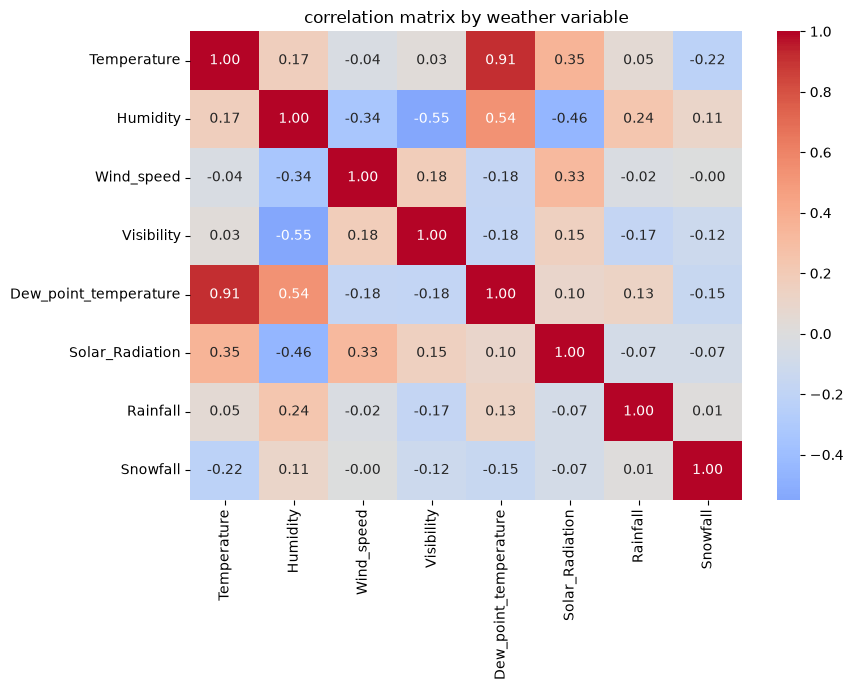

,var1,var2,corr
4,Temperature,Dew_point_temperature,0.914467


In [40]:
#기상변수 간 상관계수 행렬
corr_matrix = df_w[weather_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("correlation matrix by weather variable")
plt.tight_layout()
plt.show()

# 절댓값 0.7 이상인 변수쌍만 추출
high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["var1", "var2", "corr"]
high_corr[high_corr["corr"].abs() >= 0.7].sort_values("corr", key=abs, ascending=False)

In [39]:
#VIF 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df_w[weather_cols])
vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_df = vif_df[vif_df["variable"] != "const"].sort_values("VIF", ascending=False)
vif_df

,variable,VIF
5,Dew_point_temperature,116.219367
1,Temperature,87.152504
2,Humidity,20.132908
6,Solar_Radiation,1.975087
4,Visibility,1.565867
3,Wind_speed,1.198871
8,Snowfall,1.093974
7,Rainfall,1.080975


**해석 기준**: 일반적으로 VIF > 10이면 다중공선성이 심각, 5~10이면 주의가 필요한 수준으로 봄.
 Dew_point_temperature는 temperature,humidity와 물리적으로 강하게 연동되는 변수라 VIF가 높게 나올 가능성이 큼 → 모델링 때 Dew_point_temperature 제외 검토

## Part 4 최종 요약 
### 1. EDA 결과 요약

**(1) 분포**

정상 분포: Temperature, Humidity, Dew_point_temperature — 비교적 대칭
한쪽으로 치우친 분포: Wind_speed, Visibility (특히 Visibility는 2000 상한에 관측치 몰림 — 측정의 한계)
Zero-inflated(대부분의 변수가 0): Solar_Radiation(49%), Rainfall(93.9%), Snowfall(94.8%)이 0 — 연속값이 아니라 [발생 여부 + 강도]가 섞인 구조

**(2) 종속변수(Rented_Bike_Count)와의 상관관계**

가장 강한 변수: Temperature (Pearson 상관계수: 0.56)
Pearson-Spearman 차이(abs_diff)가 큰 변수(차이가 크면 비선형관계임을 시사): Solar_Radiation,Rainfall,Snowfall → zero-inflation이 만든 인위적 차이 (진짜 비선형이 아님) & 나머지 연속형 5개는 abs_diff 모두 0.05 이하

**(3) 산점도로 확인한 실제 관계 모양**

Temperature, Dew_point_temperature: 완만한 단조 증가
Humidity, Wind_speed: 역U자형 — 특정 구간(습도 40~60%, 풍속 2~3m/s)에서 대여량이 가장 높고 양극단에서 낮아지는 비선형 관계
Visibility: 계기 상한(2000)으로 인해 추세가 인위적으로 눌림
Solar_Radiation: 주간/야간 이분화가 추세의 대부분을 설명

중요한 해석 포인트: Humidity·Wind_speed는 abs_diff가 작아서(2) "비선형이 없다"고 판단했지만, 실제로는 산점도(3)에서 뚜렷한 역U자 관계가 보였음. 이는 abs_diff 방식의 한계 때문임 — Spearman도 결국 단조 관계만 잡아내는 지표라, 역U자처럼 방향이 바뀌는 비단조 관계는 Pearson/Spearman 모두 낮게 나와 차이가 작아 보이는 것뿐. 즉 abs_diff가 작다고 선형관계라 단정할 수 없고, 반드시 산점도로 형태를 직접 확인해야 한다는 걸 이번 EDA가 보여준 셈.

**(4) 이상치**

Temperature, Humidity, Visibility, Dew_point_temperature: IQR 기준 이상치 0건
Wind_speed 1.82%, Solar_Radiation·Rainfall·Snowfall은 7% 내외지만 이는 zero-inflated 구조상 IQR 기준 자체가 안 맞는 경우
Humidity=0(17건), Visibility=2000(2,150건, 25.4%)은 값이 이상해서가 아니라 계기의 측정 한계로 판단 → 제거 대상 아님

**(5) 다중공선성**

Temperature <-> Dew_point_temperature: corr 0.91, VIF 각각 87.2 / 116.2 → 심각한 수준
Humidity: 어느 한 변수와도 0.7 안 넘지만 여러 변수와 중간 강도로 얽혀 VIF 20.1 (다중공선성은 한 쌍이 아니라 여러 변수의 누적으로도 발생함을 보여주는 사례)
Wind_speed, Visibility, Solar_Radiation, Rainfall, Snowfall: VIF 모두 2 미만, 서로 독립적

### 2. 변수별 처리 방향

**Temperature: 그대로 사용**

**Dew_point_temperature: 제외 검토** - Temperature와 상관계수 0.91, VIF가 각각 87.2와 116.2까지 나올 정도로 다중공선성이 심각

**Humidity: 그대로 사용하되 비선형 반영 고려 (구간화/다항항)** - 산점도에서 역U자형 관계 보임 ->  구간을 나누거나(binning) 제곱항을 추가하는 식으로 비선형성 반영. VIF가 20.1로 다소 높긴 하지만 심각한 수준은 X

**Wind_speed: 비선형 반영 고려 (구간화/다항항)** - Humidity와 마찬가지로 역U자형 패턴 -> 구간화나 다항항 추가로 비선형성 반영.

**Visibility: 그대로 사용, 계기 상한 인지하고 해석** - 값의 25.4%가 2000이라는 계기 측정 상한에 몰려 있음. 이 상한 자체를 제거하거나 왜곡시키지 말고 이런 계기 특성이 있다는 걸 인지한 채로 원본값을 그대로 사용

**Solar_Radiation: 원본값 유지** - 절반 가까이(49%)가 0인 값이지만, 이 0 여부 자체가 주/야 신호를 자연스럽게 반영

**Rainfall/Snowfall:  원본값과 Rain_YN/ Snow_YN(이진 변수)를 추가로 만들어서 함께 사용** - 각각 93.9%, 94.8%가 0인 zero-inflated 변수인데, 분석 결과 "얼마나 오는지"보다 "오는지 안 오는지" 자체가 대여량을 설명하는 핵심 신호 -> 원본값은 트리 기반 모델이 알아서 비선형 패턴을 잡아내는 데 쓰이고, 이진 변수는 회귀 계열 모델에서 명확한 신호로 작동

### 3. 앞으로의 분석 방향 (다음 단계 제안)

(1) 전처리

Rain_YN, Snow_YN 파생변수를 최종 데이터셋에 포함
Dew_point_temperature는 회귀 계열 모델을 쓸 경우 제외, 트리 계열(Random Forest 등)에서는 유지해도 무방 (트리 모델은 다중공선성에 상대적으로 강함)
Functioning_Day="No"인 295개 행은 대여량이 항상 0이므로, 수요 예측이 목적이라면 학습 데이터에서 제외하는 것이 합리적 (운영을 안 하는 시간의 '0'은 수요가 없는 게 아니라 관측이 안 된 것)

(2) 추가로 봐야 할 것 (날씨 파트에서 다 못 본 부분)

날씨 변수 × 시간대(Hour)/계절(Seasons) 교차효과: 예를 들어 "출퇴근 시간대 + 비"처럼 두 조건이 겹칠 때의 효과 (Rain_YN 박스플롯에서 봤던 이상치들이 이 교차효과일 가능성)
Humidity와 Wind_speed의 최적구간을 구간별 더미변수(binning)로 만들어서 회귀모델에 넣을지, 아니면 다항항(제곱항)으로 넣을지 결정

(3) 모델링 단계 연결

선형회귀를 베이스라인으로 쓴다면: Dew_point_temperature 제외 + Humidity/Wind_speed 비선형 처리 + Rain_YN/Snow_YN 이진화 필수
트리 기반 모델(Random Forest, Gradient Boosting)을 쓴다면: 원본 변수 그대로 넣어도 비선형/상호작용을 모델이 알아서 학습하므로 전처리 부담이 적음 
-> 두 계열을 비교해서 "왜 트리 모델이 더 잘 맞는지/안 맞는지"를 날씨 EDA 결과로 설명하는 스토리도 가능